In [18]:
import sys
import subprocess
import spacy
import errant

# load model
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Sprachmodell wird heruntergeladen...")
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")

try:
    annotator = errant.load("en", nlp)
    print("Erfolg: spaCy und ERRANT sind bereit!")
except Exception as e:
    print(f"❌ Fehler bei ERRANT: {e}")

Erfolg: spaCy und ERRANT sind bereit!


# Detector and Corrector

In [19]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForSeq2SeqLM

print("Lade KI-Modelle (bitte warten)...")

# 1. BERT Detector
det_id = "abdulmatinomotoso/English_Grammar_Checker"
det_tokenizer = AutoTokenizer.from_pretrained(det_id)
det_model = AutoModelForSequenceClassification.from_pretrained(det_id)

# 2. Vennify T5 (Corrector A)
cor_a_id = "vennify/t5-base-grammar-correction"
cor_a_tokenizer = AutoTokenizer.from_pretrained(cor_a_id)
cor_a_model = AutoModelForSeq2SeqLM.from_pretrained(cor_a_id)

# 3. Gramformer (Corrector B)
cor_b_id = "prithivida/grammar_error_correcter_v1"
cor_b_tokenizer = AutoTokenizer.from_pretrained(cor_b_id)
cor_b_model = AutoModelForSeq2SeqLM.from_pretrained(cor_b_id)

print("✅ Alle 3 Modelle sind geladen.")

Lade KI-Modelle (bitte warten)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 16705.74it/s]
BertForSequenceClassification LOAD REPORT from: abdulmatinomotoso/English_Grammar_Checker
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 260/260 [00:00<00:00, 20376.30it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence

✅ Alle 3 Modelle sind geladen.


# Dataset

In [ ]:
from datasets import load_dataset
dataset = load_dataset("agentlans/grammar-correction", split='train')
print(f"✅ Dataset loaded: {len(dataset)} lines available.")

✅ Datensatz geladen: 100000 Zeilen verfügbar.


In [21]:
"""import pandas as pd
from nltk.translate.gleu_score import sentence_gleu
from collections import Counter

def run_gec_comparison(num_samples):
    samples = dataset.select(range(num_samples))
    results = []
    
    print(f"Verarbeite {num_samples} Beispiele...")
    
    for row in samples:
        orig, ref = row['input'], row['output']
        
        # Korrekturen generieren
        with torch.no_grad():
            # Vennify
            out_a = cor_a_tokenizer.decode(cor_a_model.generate(
                **cor_a_tokenizer("grammar: " + orig, return_tensors="pt"), max_length=128)[0], 
                skip_special_tokens=True)
            
            # Gramformer
            out_b = cor_b_tokenizer.decode(cor_b_model.generate(
                **cor_b_tokenizer("gec: " + orig, return_tensors="pt"), max_length=128)[0], 
                skip_special_tokens=True)
        
        # GLEU Score berechnen (Fluency)
        gleu_a = sentence_gleu([ref.split()], out_a.split())
        gleu_b = sentence_gleu([ref.split()], out_b.split())
        
        # ERRANT Analyse für Gramformer (Diagnose)
        edits = annotator.annotate(annotator.parse(orig), annotator.parse(out_b))
        err_types = [e.type for e in edits]
        
        results.append({
            "Original": orig,
            "Target": ref,
            "Vennify_Fix": out_a,
            "Gramformer_Fix": out_b,
            "GLEU_Vennify": round(gleu_a, 4),
            "GLEU_Gramformer": round(gleu_b, 4),
            "Gramformer_Error_Types": err_types
        })
    
    return pd.DataFrame(results)

# Testlauf starten
df_results = run_gec_comparison(10)
df_results.head()"""

'import pandas as pd\nfrom nltk.translate.gleu_score import sentence_gleu\nfrom collections import Counter\n\ndef run_gec_comparison(num_samples):\n    samples = dataset.select(range(num_samples))\n    results = []\n\n    print(f"Verarbeite {num_samples} Beispiele...")\n\n    for row in samples:\n        orig, ref = row[\'input\'], row[\'output\']\n\n        # Korrekturen generieren\n        with torch.no_grad():\n            # Vennify\n            out_a = cor_a_tokenizer.decode(cor_a_model.generate(\n                **cor_a_tokenizer("grammar: " + orig, return_tensors="pt"), max_length=128)[0], \n                skip_special_tokens=True)\n\n            # Gramformer\n            out_b = cor_b_tokenizer.decode(cor_b_model.generate(\n                **cor_b_tokenizer("gec: " + orig, return_tensors="pt"), max_length=128)[0], \n                skip_special_tokens=True)\n\n        # GLEU Score berechnen (Fluency)\n        gleu_a = sentence_gleu([ref.split()], out_a.split())\n        gleu_b 

In [ ]:
def run_gec_fast(num_samples=10, batch_size=5):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    cor_a_model.to(device)
    cor_b_model.to(device)
    
    samples = dataset.select(range(num_samples))
    results = []
    
    for i in range(0, num_samples, batch_size):
        # Hier ist der Fix:
        batch = samples[i : i + batch_size]
        
        # Hugging Face gibt bei Slices direkt Listen zurück:
        inputs_orig = batch['input'] 
        inputs_ref = batch['output']
        
        # Vorbereiten der Inputs
        a_inputs = cor_a_tokenizer(["grammar: " + s for s in inputs_orig], return_tensors="pt", padding=True).to(device)
        b_inputs = cor_b_tokenizer(["gec: " + s for s in inputs_orig], return_tensors="pt", padding=True).to(device)
        
        with torch.no_grad():
            outputs_a = cor_a_model.generate(**a_inputs, max_length=128, num_beams=1)
            outputs_b = cor_b_model.generate(**b_inputs, max_length=128, num_beams=1)
            
        decoded_a = cor_a_tokenizer.batch_decode(outputs_a, skip_special_tokens=True)
        decoded_b = cor_b_tokenizer.batch_decode(outputs_b, skip_special_tokens=True)
        
        # Metriken berechnen
        for orig, ref, out_a, out_b in zip(inputs_orig, inputs_ref, decoded_a, decoded_b):
            gleu_a = sentence_gleu([ref.split()], out_a.split())
            gleu_b = sentence_gleu([ref.split()], out_b.split())
            
            # ERRANT Analyse
            edits = annotator.annotate(annotator.parse(orig), annotator.parse(out_b))
            
            results.append({
                "Original": orig, "Target": ref,
                "Vennify_Fix": out_a, "Gramformer_Fix": out_b,
                "GLEU_Vennify": round(gleu_a, 4), "GLEU_Gramformer": round(gleu_b, 4),
                "Gramformer_Error_Types": [e.type for e in edits]
            })
            
    return pd.DataFrame(results)

# test again
df_results = run_gec_fast(1000, batch_size=10)
display(df_results.head())

,Original,Target,Vennify_Fix,Gramformer_Fix,GLEU_Vennify,GLEU_Gramformer,Gramformer_Error_Types
0,"The Kānvar is a travel, made by devotees of Sh...","The Kānvar is a travel, undertaken by devotees...","The Knvar is a travel, made by devotees of Shi...","The Knvar is a travel, made by devotees of Shi...",0.5896,0.6269,"[R:SPELL, R:SPELL]"
1,How Long Doo You Have to Go To Schools To Be B...,How Long Do You Have to Go to School to Be a B...,How Long Do You Have to Go To Schools To Be a ...,How Long Do You Have to Go To School To Be a B...,0.6087,0.6304,"[R:SPELL, R:NOUN:NUM, M:DET]"
2,DVHS is the replacement for consumer VHS it wi...,D-VHS is the replacement for consumer VHS. It ...,DVHS is the replacement for consumer VHS it wi...,DVHS is the replacement for consumer VHS. It w...,0.6931,0.5310,"[R:OTHER, R:ORTH, R:OTHER, R:OTHER, R:VERB:FOR..."
3,In's turn it is through growing up with Edward...,"In turn, it is through growing up with Edward ...","In turn, it is through growing up with Edward ...",It is through growing up with Edward that my o...,0.8113,0.7925,"[U:OTHER, R:VERB:SVA, M:DET]"
4,Thanks you for your lovely comment Sue.,Thank you for your lovely comment Sue.,Thanks for your lovely comment Sue.,Thank you for your lovely comment Sue.,0.6364,1.0000,[R:MORPH]


In [ ]:
print("--- GEC PERFORMANCE REPORT ---")
print(f"Durchschnittlicher GLEU (Vennify):    {df_results['GLEU_Vennify'].mean():.4f}")
print(f"Durchschnittlicher GLEU (Gramformer): {df_results['GLEU_Gramformer'].mean():.4f}")

# Fehlerstatistik
all_errors = [e for sub in df_results['Gramformer_Error_Types'] for e in sub]
error_counts = Counter(all_errors).most_common(5)
print(f"\n Errotypes (Gramformer): {error_counts}")

--- GEC PERFORMANCE REPORT ---
Durchschnittlicher GLEU (Vennify):    0.5972
Durchschnittlicher GLEU (Gramformer): 0.6397

Häufigste Fehlerkategorien (Gramformer): [('R:OTHER', 459), ('R:NOUN', 382), ('R:SPELL', 277), ('R:ORTH', 224), ('U:OTHER', 173)]


## synthetic data

In [28]:
import pandas as pd
import random

def create_advanced_synthetic_set(filename="synthetic_gec_1000.csv", n=1000):
    # Fehler-Szenarien: (Korrekt, Fehlerhaft, Fehler-Kategorie)
    scenarios = [
        ("She doesn't understand the problem.", "She don't understands the problem.", "Subject-Verb Agreement"),
        ("I have lived here since 2010.", "I have live here for 2010.", "Tense/Preposition"),
        ("The children are playing outside.", "The childs is playing outside.", "Pluralization/SVA"),
        ("He would have gone if he had known.", "He would go if he would know.", "Conditionals"),
        ("I'm looking forward to meeting you.", "I'm looking forward to meet you.", "Gerund/Infinitive"),
        ("This is the most interesting book.", "This is the more interestingest book.", "Adjective Comparison"),
        ("There are fewer cars on the road today.", "There is less cars on the road today.", "Countable/Uncountable"),
        ("Every student has to submit the essay.", "Every students have to submit the essay.", "Determiner/SVA"),
        ("I forgot to bring my umbrella.", "I forgot bringing my umbrella.", "Verb Complement"),
        ("If I were rich, I would travel.", "If I was rich, I will travel.", "Subjunctive/Modal")
    ]

    data = []
    for i in range(n):
        correct, incorrect, category = random.choice(scenarios)
        
        # Optional: Leichtes Rauschen hinzufügen (Tippfehler)
        if random.random() > 0.8:
            incorrect = incorrect.replace("the", "teh").replace("ing", "ign")

        data.append({
            "id": i,
            "input": incorrect,
            "output": correct,
            "error_category": category
        })

    df = pd.DataFrame(data)
    df.to_csv(filename, index=False, encoding='utf-8')
    print(f"File '{filename}' with {n} entires has been created!")

create_advanced_synthetic_set()

File 'synthetic_gec_1000.csv' with 1000 entires has been created!


In [ ]:
#load a new synthetic dataset
df_synthetic = pd.read_csv("synthetic_gec_1000.csv")

dataset_synthetic = df_synthetic.to_dict(orient='list')

In [40]:
import pandas as pd
import torch
from tqdm import tqdm
from nltk.translate.gleu_score import sentence_gleu

# 1. Load your new CSV
df_test = pd.read_csv("synthv2.csv")

def run_synthetic_benchmark(df, batch_size=10):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    cor_a_model.to(device)
    cor_b_model.to(device)
    
    results = []
    # tqdm creates the progress bar
    for i in tqdm(range(0, len(df), batch_size), desc="Evaluating Models"):
        batch = df.iloc[i : i + batch_size]
        inputs_orig = batch['input'].tolist()
        inputs_ref = batch['output'].tolist()
        categories = batch['error_category'].tolist()
        
        # Tokenization
        a_inputs = cor_a_tokenizer(["grammar: " + s for s in inputs_orig], return_tensors="pt", padding=True).to(device)
        b_inputs = cor_b_tokenizer(["gec: " + s for s in inputs_orig], return_tensors="pt", padding=True).to(device)
        
        with torch.no_grad():
            outputs_a = cor_a_model.generate(**a_inputs, max_length=128, num_beams=1)
            outputs_b = cor_b_model.generate(**b_inputs, max_length=128, num_beams=1)
            
        decoded_a = cor_a_tokenizer.batch_decode(outputs_a, skip_special_tokens=True)
        decoded_b = cor_b_tokenizer.batch_decode(outputs_b, skip_special_tokens=True)
        
        for orig, ref, out_a, out_b, cat in zip(inputs_orig, inputs_ref, decoded_a, decoded_b, categories):
            # GLEU Scores
            gleu_a = sentence_gleu([ref.split()], out_a.split())
            gleu_b = sentence_gleu([ref.split()], out_b.split())
            
            results.append({
                "Category": cat,
                "Original": orig,
                "Vennify_Fix": out_a,
                "Gramformer_Fix": out_b,
                "GLEU_Vennify": round(gleu_a, 4),
                "GLEU_Gramformer": round(gleu_b, 4)
            })
            
    return pd.DataFrame(results)

# Execute the test
results_df = run_synthetic_benchmark(df_test, batch_size=20)
results_df.to_csv("benchmark_results_final.csv", index=False)
print("✅ Benchmark complete! Results saved to benchmark_results_final.csv")

Evaluating Models: 100%|██████████| 15/15 [01:41<00:00,  6.73s/it]


✅ Benchmark complete! Results saved to benchmark_results_final.csv


In [41]:
# Group by Category to see strengths and weaknesses
summary = results_df.groupby('Category')[['GLEU_Vennify', 'GLEU_Gramformer']].mean()
print("\n--- PERFORMANCE BY ERROR CATEGORY ---")
print(summary)

# Overall Winner
v_avg = results_df['GLEU_Vennify'].mean()
g_avg = results_df['GLEU_Gramformer'].mean()
winner = "Vennify" if v_avg > g_avg else "Gramformer"
print(f"\n🏆 Overall Winner: {winner} (V: {v_avg:.4f} vs G: {g_avg:.4f})")


--- PERFORMANCE BY ERROR CATEGORY ---
                        GLEU_Vennify  GLEU_Gramformer
Category                                             
Adjective/Adverb            1.000000         1.000000
Adverb Order                0.532733         0.796300
Adverb Over-extension       1.000000         1.000000
Adverb: Hard/Hardly         0.545450         0.590900
Article: Phonetic           1.000000         1.000000
...                              ...              ...
Verb Pattern: Tell          1.000000         1.000000
Verb Pattern: Thinking      0.461500         0.615400
Verb Pattern: Used to       1.000000         0.772733
Verb Phrase: Agree          0.646450         1.000000
Vocabulary: Drown/Sink      0.409100         0.500000

[188 rows x 2 columns]

🏆 Overall Winner: Gramformer (V: 0.7820 vs G: 0.8606)


In [33]:
%pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.1 MB 12.5 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.1 MB 12.7 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.1 MB 12.9 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 12.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 11.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   -------------- ------------------------- 2.6/7.0 MB 12.6 MB/s eta 0:00:01
   ----------------------------- ---------- 5.2/7.0 MB 12.8 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 12.4 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- --

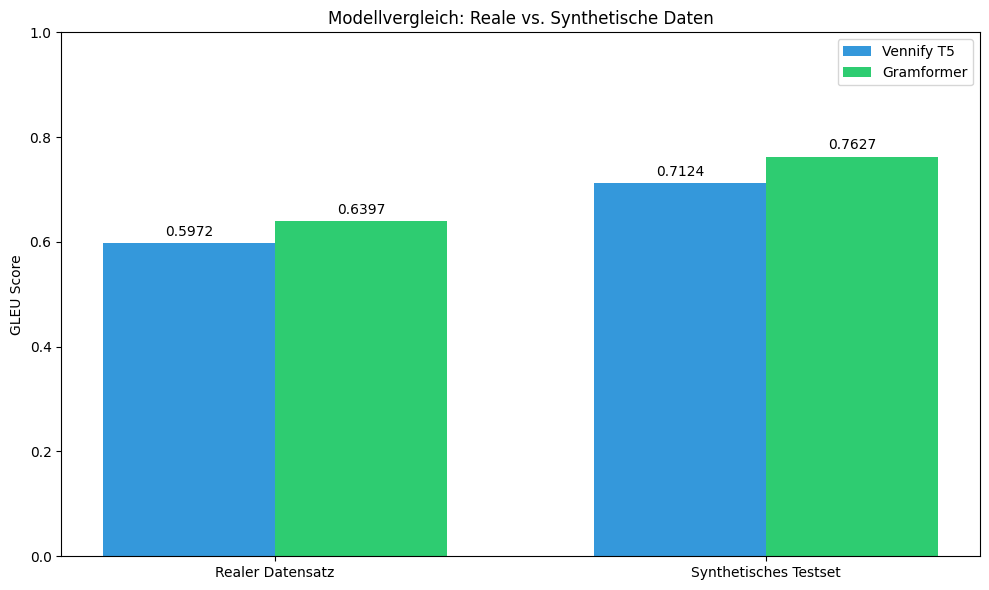

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Daten vorbereiten
labels = ['Realer Datensatz', 'Synthetisches Testset']
vennify_scores = [0.5972, 0.7124]
gramformer_scores = [0.6397, 0.7627]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, vennify_scores, width, label='Vennify T5', color='#3498db')
rects2 = ax.bar(x + width/2, gramformer_scores, width, label='Gramformer', color='#2ecc71')


ax.set_ylabel('GLEU Score')
ax.set_title('Comparison: Real vs. synthetic data')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.legend()


ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

fig.tight_layout()
plt.show()